<a id="intro"></a>
# Bank customer churn analysis

**Project description**

Stakeholders are the management of Metanprom Bank. The bank operates in Yaroslavl and the regional cities Rostov Veliky and Rybinsk.

The goal of the study is to analyze bank customers and identify segments that are likely to churn.

**Contents**:
1. [Exploratory analysis](#analyze_data)
2. [High churn segment analysis](#analyze_segment)
3. [Statistical hypothesis testing](#hypothesis)
4. [Presentation](https://disk.yandex.ru/i/4N8lRLVmxNufjw)

 👉 **[Research summary](#research_results)**

 
**Data description**

- `USERID` — user identifier,
- `score` — credit score points,
- `city` — city,
- `gender` — gender,
- `age` — age,
- `equity` — equity score count
- `balance` — account balance,
- `products` — number of products used by the client,
- `credit_card` — whether the client has a credit card,
- `last_activity` — active client,
- `EST_SALARY` — estimated client income,
- `churn` — churn indicator.


## General data information

In [146]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker
import sys
import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest
try:
    import phik
except ImportError:
    !"{sys.executable}" -m pip install phik
    import phik

In [147]:
# check Markdown support
if 'ipykernel' in sys.modules:
    flag_md = 1
else:
    flag_md = 0

In [148]:
# read data file and store in dataframe
dir1 = '/datasets/'
dir2 = '/Users/alexslobodskoj/Data_Analyst/'
places_pth = 'bank_scrooge.csv'

# create dataframe
if os.path.exists(dir1):
    df_bank = pd.read_csv(dir1 + places_pth)
elif os.path.exists(dir2):
    df_bank = pd.read_csv(dir2 + places_pth)
else:
    print('Something is wrong')

In [149]:
# bank customers dataframe
# display first 5 rows
display(df_bank.head())

# display basic info
df_bank.info()

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  str    
 3   gender         10000 non-null  str    
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), str(2)
memory usage: 1.1 MB


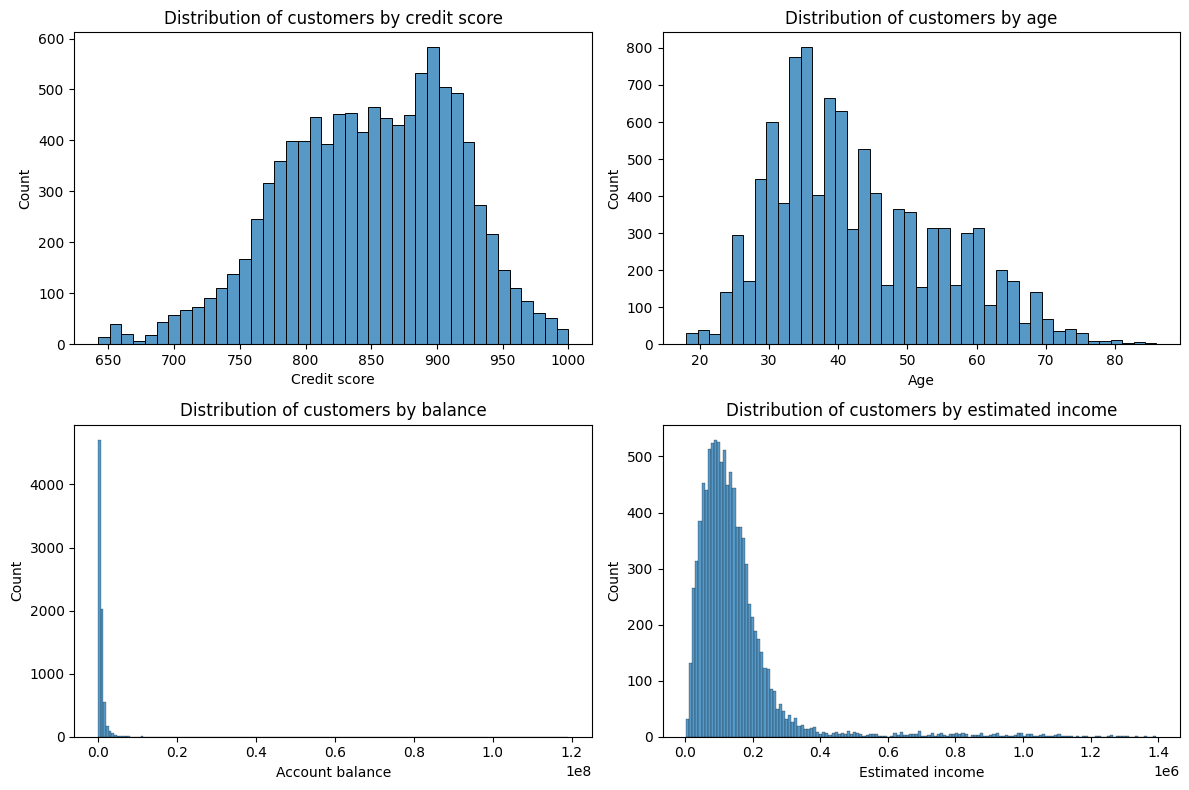

In [150]:
# distribution of main numeric features
# set figure size
plt.figure(figsize=(12, 8))

# histogram for column 'score'
plt.subplot(2, 2, 1)
sns.histplot(df_bank['score'])
plt.title('Distribution of customers by credit score')
plt.ylabel('Count')
plt.xlabel('Credit score')

# histogram for column 'age'
plt.subplot(2, 2, 2)
sns.histplot(df_bank['age'])
plt.title('Distribution of customers by age')
plt.ylabel('Count')
plt.xlabel('Age')

# histogram for column 'balance'
plt.subplot(2, 2, 3)
sns.histplot(df_bank['balance'])
plt.title('Distribution of customers by balance')
plt.ylabel('Count')
plt.xlabel('Account balance')

# histogram for column 'EST_SALARY'
plt.subplot(2, 2, 4)
sns.histplot(df_bank['EST_SALARY'])
plt.title('Distribution of customers by estimated income')
plt.ylabel('Count')
plt.xlabel('Estimated income')
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**

1. The table contains data on **10000** customers

2. Columns should be renamed to lowercase

3. Column data types should be changed:

    - `age` and `score` to integer,
    - `credit_card`, `last_activity`, `churn` to boolean

5. The table should be checked for duplicates

6. There are outliers in the `balance` and `EST_SALARY` columns

7. The table contains missing values — determine whether to fill them or exclude them from the analysis

## Data preprocessing

### Rename columns

In [151]:
df_bank.columns = [x.lower() for x in df_bank.columns.values]

### Change column data types

Change the types of `age` and `score` to integer.

In [152]:
# record column names in a list
columns_to_convert = ['age', 'score']

# change data types in columns
for col in columns_to_convert:
    df_bank[col] = \
    (
        df_bank[col]
        .astype(pd.Int64Dtype())
    )

Change the types of `credit_card`, `last_activity`, `churn` to boolean.

In [153]:
# record column names in a list
columns_to_convert = ['credit_card', 'last_activity', 'churn']

# change data types in columns
for col in columns_to_convert:
    df_bank[col] = \
    (
        df_bank[col]
        .astype(bool)
    )

### Duplicate check

Check for explicit duplicates

In [154]:
# display table names and number of explicit duplicates
message = (
    f'Remove **{df_bank.duplicated().sum()}**'
    f' explicit duplicate rows'
) if df_bank.duplicated().sum() > 0 else f'No explicit duplicates in the table'

if flag_md == 1:
    display(Markdown(message))
else:
    print(message.replace("*", ""))

No explicit duplicates in the table

Check for hidden duplicates in the `city` and `gender` columns

In [155]:
# record column names in a list
columns_to_convert = ['city', 'gender']

# display values for each column
for col in columns_to_convert:
    display(df_bank[col].value_counts(sort=True, ascending=False, dropna=True))
    print()

city
Ярославль    5888
Рыбинск      2695
Ростов       1417
Name: count, dtype: int64

gender
М    5005
Ж    4995
Name: count, dtype: int64

No hidden duplicates found in `city` and `gender`.

Check for duplicate `userid` values within a single city.

In [156]:
# find duplicates
df_agg = \
(
    df_bank
    .groupby(['userid', 'city'])
    .size()
    .reset_index(name='count')
    .query('count > 1')
)

# check for duplicates
if (df_agg['count'] > 1).any():
    
    message = (
        f'There are **{len(df_agg)}** duplicate `userid` values within a single city.\n\n'
        f'Keep the first duplicate occurrence for further analysis.'
    )
    
else:
    message = (
        f'No duplicate `userid` values within a single city.'
    )
    
# print duplicate message 
if flag_md == 1:
    display(Markdown(message))
else:
    print(message.replace("*", ""))

No duplicate `userid` values within a single city.

### Missing value handling

Calculate the percentage of missing values by bank branch.

In [157]:
# display missing value share information
for city in df_bank['city'].sort_values(ascending=False).unique():
    city_data = df_bank.query('city == @city')
    na_series = city_data.isna().sum() > 0
    df_na = pd.DataFrame(city_data.isna().mean()[na_series], columns=[city])
    display(df_na.style.format("{:.2%}").background_gradient('coolwarm'))

,Ярославль
age,0.22%
balance,24.92%


,Рыбинск
age,0.45%
balance,22.00%


,Ростов
age,0.07%
balance,16.58%


The missing value share across branches is roughly the same considering city sizes.

Calculate the missing value percentage for churned and retained customers.

In [158]:
# display missing value share information
for churn in df_bank['churn'].unique():
    churn_data = df_bank.query('churn == @churn')
    na_series = churn_data.isna().sum() > 0
    df_na = pd.DataFrame(
        churn_data.isna()
        .mean()[na_series], 
        columns=["Churned" if churn == True else "Retained"])
    display(df_na.style.format("{:.2%}").background_gradient('coolwarm'))
    

,Churned
age,0.05%
balance,0.71%


,Retained
age,0.31%
balance,27.90%


Missing values are not related to customer churn status.

Filling missing values with zeros or other values may distort study results. Leave missing values unchanged.

<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**
  
1. Renamed column names to lowercase
   
2. Changed types of `age` and `score` to integer, and `credit_card`, `last_activity`, `churn` to boolean

3. No explicit or hidden duplicates were found in the tables

4. Handled missing values

<a id="analyze_data"></a>
## Exploratory data analysis

Goal: identify potential customer segments likely to churn.

### Customer distribution by churn status

Assess the numerical and graphical distribution of customer churn across the bank.

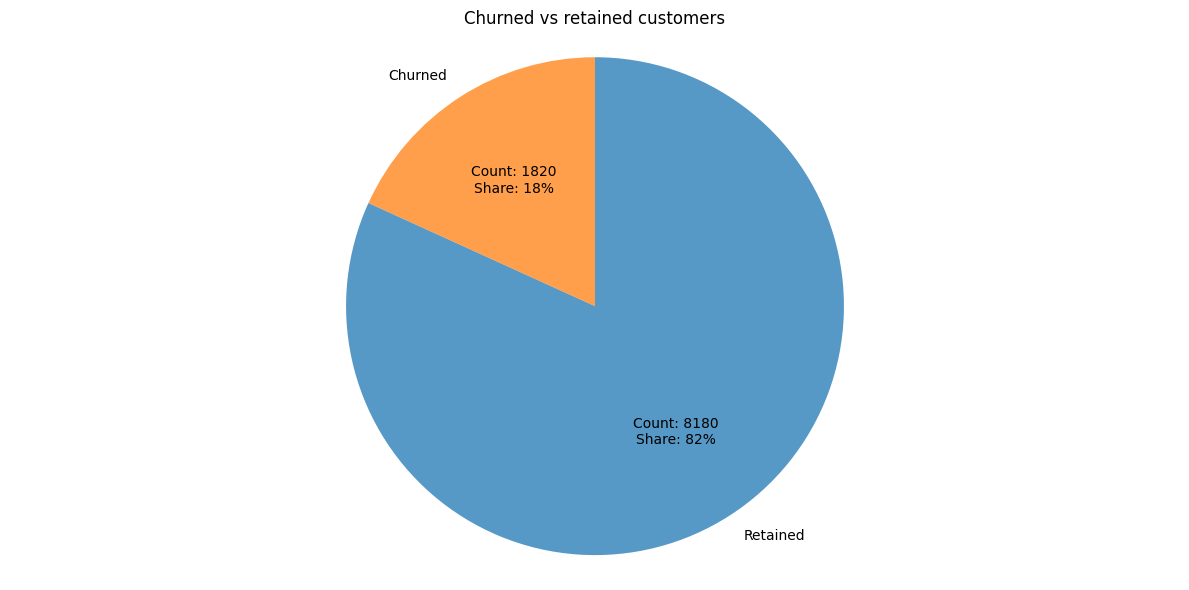

In [159]:
# group by churn status
df_agg = df_bank.groupby('churn', as_index=False).size()

# function for label formatting
def label_pct(pct, allusers):
    absolute = round(pct / 100 * allusers.sum())
    return f'Count: {absolute}\nShare: {pct:.0f}%'
    
# plot pie chart
plt.figure(figsize=(12, 6))
plt.pie(
    df_agg['size'],
    autopct=lambda pct: label_pct(pct, df_agg['size']),
    labels=[
        f'{"Churned" if group == True else "Retained"}' 
        for group in df_agg['churn']
    ],
    startangle=90,
    textprops={'fontsize': 10},
    counterclock=False,
    wedgeprops={'alpha': .75}
)
plt.title('Churned vs retained customers')
plt.axis('equal')
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**

1. Retained customers:  **82%**
   
2. Churned customers:  **18%**

### Credit score analysis

Evaluate the distribution of credit score points numerically.

In [160]:
df_bank['score'].describe()

count      10000.0
mean      848.6994
std      65.448519
min          642.0
25%          802.0
50%          853.0
75%          900.0
max         1000.0
Name: score, dtype: Float64

Let's visualize how churn probability changes depending on customer credit score.


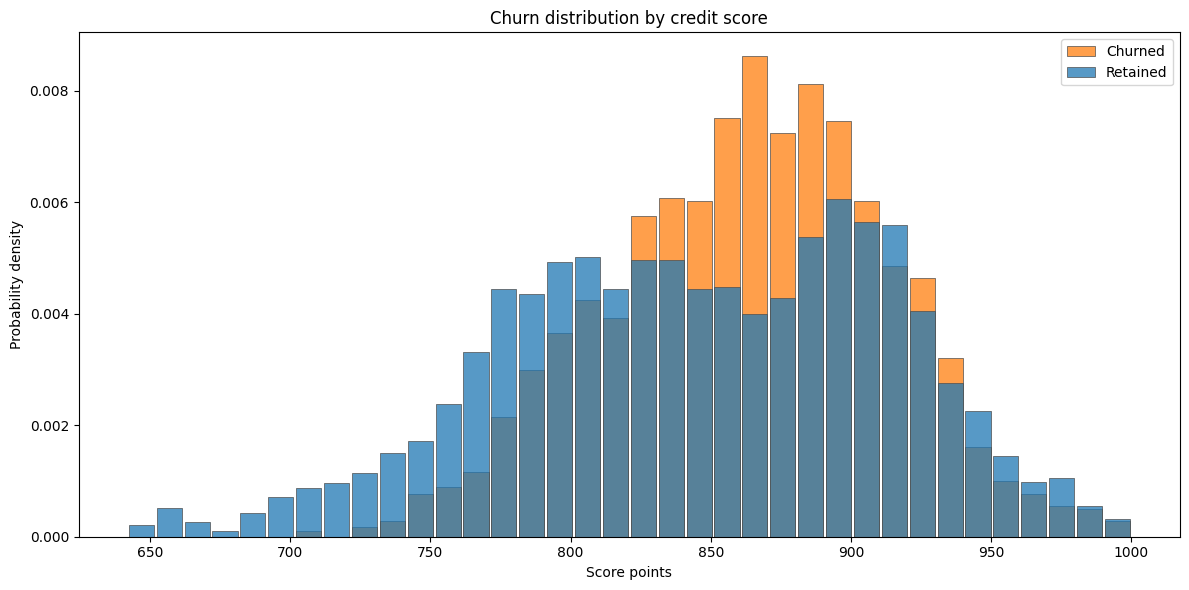

In [161]:
# set figure size 
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x="score", 
    hue="churn",
    edgecolor=".3",
    binwidth=10,
    linewidth=.5,
    stat='density',
    common_norm=False,
    shrink=.9,
    alpha=.75
)
plt.legend(
    title='', 
    loc='upper right',
    labels=[
        f'{"Churned" if group == True else "Retained"}' 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by credit score')
plt.ylabel('Probability density')
plt.xlabel('Score points')
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusions**
1. Credit score points range from **642** to **1000**

2. Most customers have a credit score around **900**

3. Potential churn-prone segment: customers with credit scores from **830** to **900**

### Analysis of number of products used

Visualize churn probability changes as the number of bank products used increases.

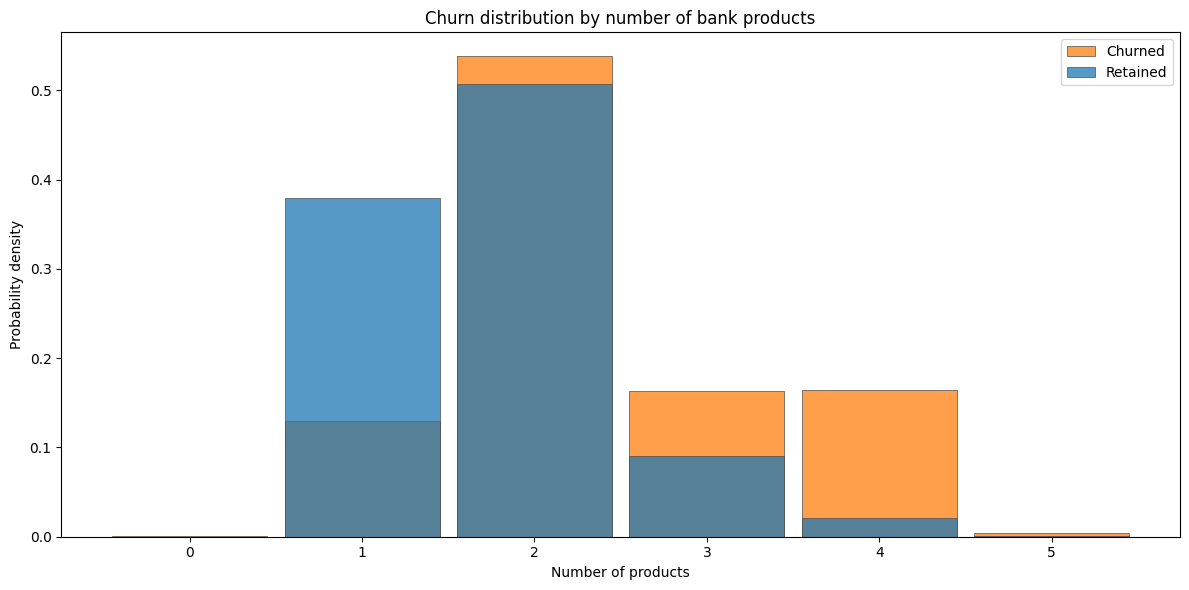

In [162]:
# set figure size 
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x="products", 
    hue="churn",
    edgecolor=".3",
    linewidth=.5,
    binwidth=1,
    discrete=True,
    stat='density',
    common_norm=False,
    shrink=.9,
    alpha=.75
)
plt.legend(
    title='', 
    labels=[
        f'{"Churned" if group == True else "Retained"}' 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by number of bank products')
plt.ylabel('Probability density')
plt.xlabel('Number of products')
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**

1. Most customers use **1** or **2** bank products
   
3. As the number of products used increases, the churn share increases

4. Churned customers may have wanted additional services, but their composition or quality was unsatisfactory

5. Potential churn-prone segment: customers using **3** or **5** bank products

### Customer analysis by city

Evaluate numerical and graphical customer distribution by branches.

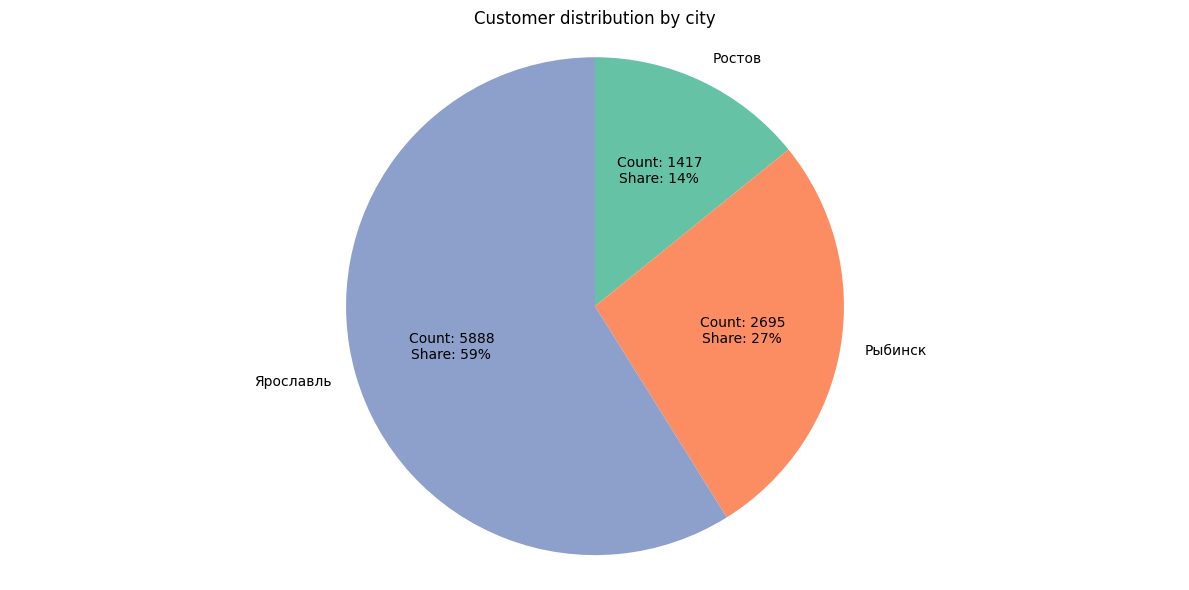

In [163]:
# group by city
df_agg = df_bank.groupby('city', as_index=False).size()

# function for label formatting
def label_pct(pct, allusers):
    absolute = round(pct / 100 * allusers.sum())
    return f'Count: {absolute}\nShare: {pct:.0f}%'
    
# plot pie chart
colors = sns.color_palette("Set2")
plt.figure(figsize=(12, 6))
plt.pie(
    df_agg['size'],
    autopct=lambda pct: label_pct(pct, df_agg['size']),
    labels=df_agg['city'],
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10},
    counterclock=False
)
plt.title('Customer distribution by city')
plt.axis('equal')
plt.tight_layout()
plt.show()

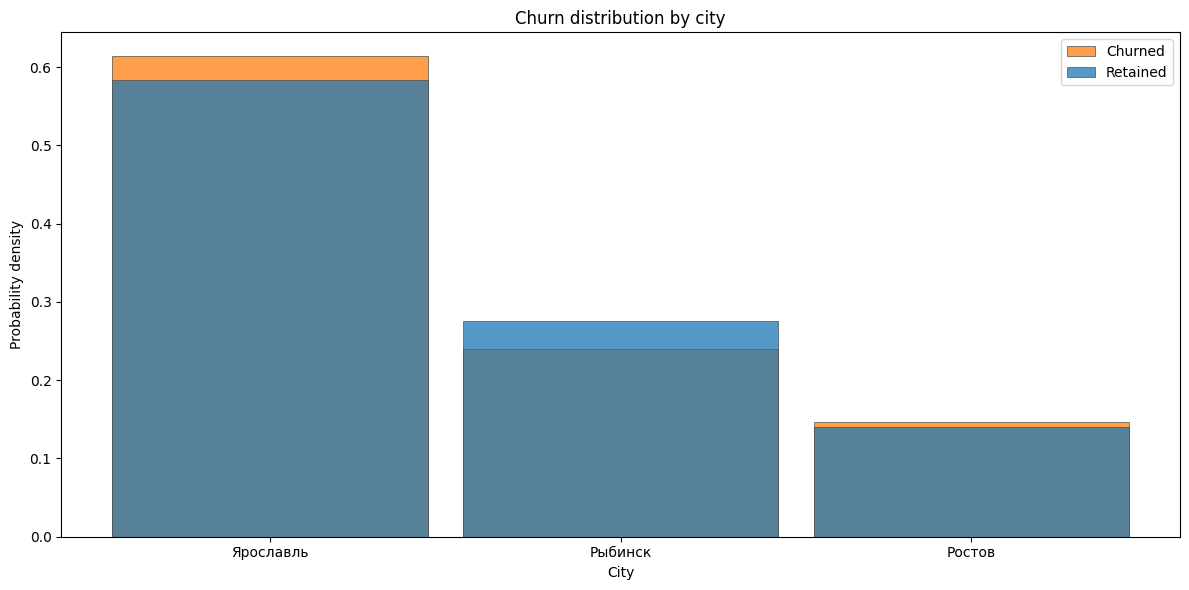

In [164]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart
ax = sns.histplot(
    df_bank,
    x=pd.Categorical(
        df_bank['city'], 
        categories=df_bank['city'].value_counts().index, 
        ordered=True
    ), 
    hue='churn',
    edgecolor='.3',
    linewidth=.5,
    discrete=True,
    stat='density',
    common_norm=False,
    shrink=.9,
    alpha=.75
)
plt.legend(
    title='', 
    labels=[
        f"{'Churned' if group == True else 'Retained'}" 
        for group in df_bank['churn'].unique()
    ]
)

plt.title('Churn distribution by city')
plt.ylabel('Probability density')
plt.xlabel('City')
plt.tight_layout()
plt.show()


<div style="border:solid gray 1px; padding: 20px">

**Conclusion:**

1. Most customers are from Yaroslavl **59%**, then Rybinsk **27%**, and Rostov **14%**
   
2. The customer city has a minor impact on churn risk.

### Gender and age analysis

Visualize customer distribution by gender and age.

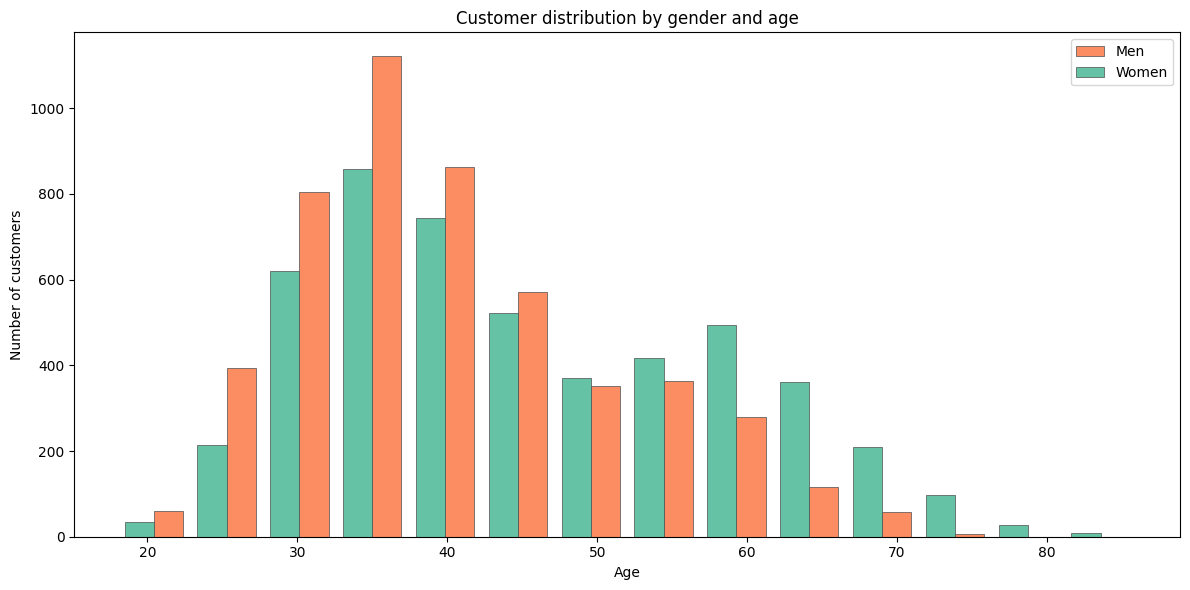

In [165]:
# set figure size 
plt.figure(figsize=(12, 6))

# plot chart
palette = sns.color_palette("Set2", n_colors=2)
sns.histplot(
    df_bank,
    x="age", 
    hue="gender",
    multiple="dodge",
    edgecolor=".3",
    linewidth=.5,
    palette=palette,
    shrink=.8,
    alpha=1,
    binwidth=5,
)
plt.legend(
    title="", 
    loc='upper right',
    labels=['Men', 'Women']
)
plt.title('Customer distribution by gender and age')
plt.ylabel('Number of customers')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

Visualize churn probability by gender.

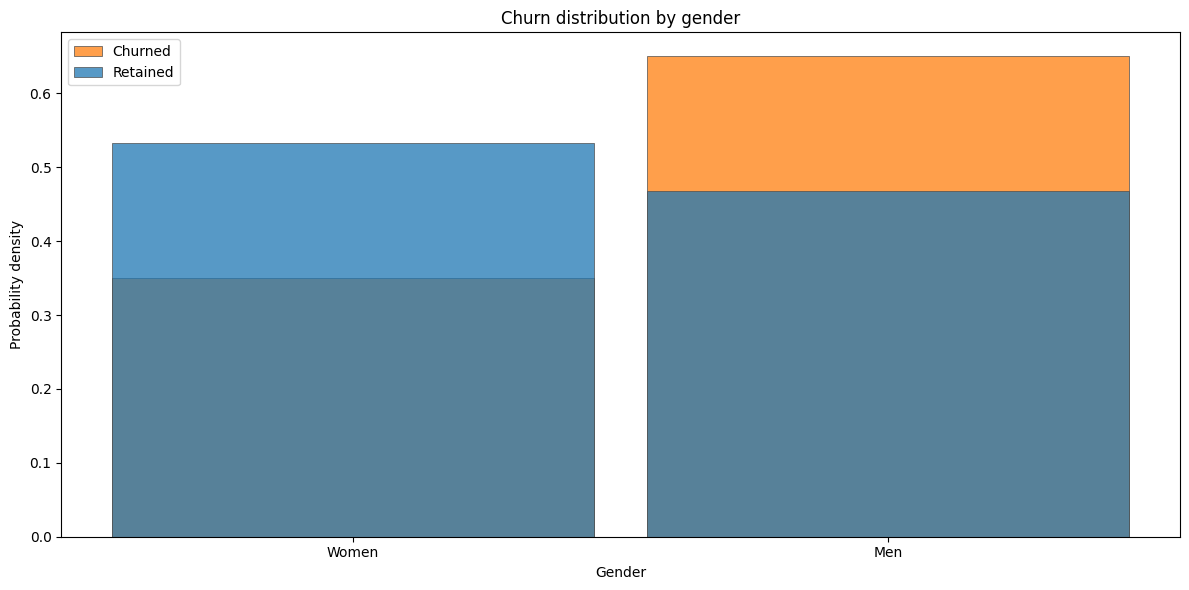

In [166]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x='gender', 
    hue='churn',
    edgecolor='.3',
    linewidth=.5,
    discrete=True,
    stat='density',
    common_norm=False,
    shrink=.9,
    alpha=.75
)
plt.legend(
    title='', 
    loc='upper left',
    labels=[
        f"{'Churned' if group == True else 'Retained'}" 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by gender')
plt.ylabel('Probability density')
plt.xlabel('Gender')
plt.xticks(ticks=[0, 1], labels=['Women', 'Men'])
plt.tight_layout()
plt.show()


Let's visualize how churn probability changes depending on customer age.


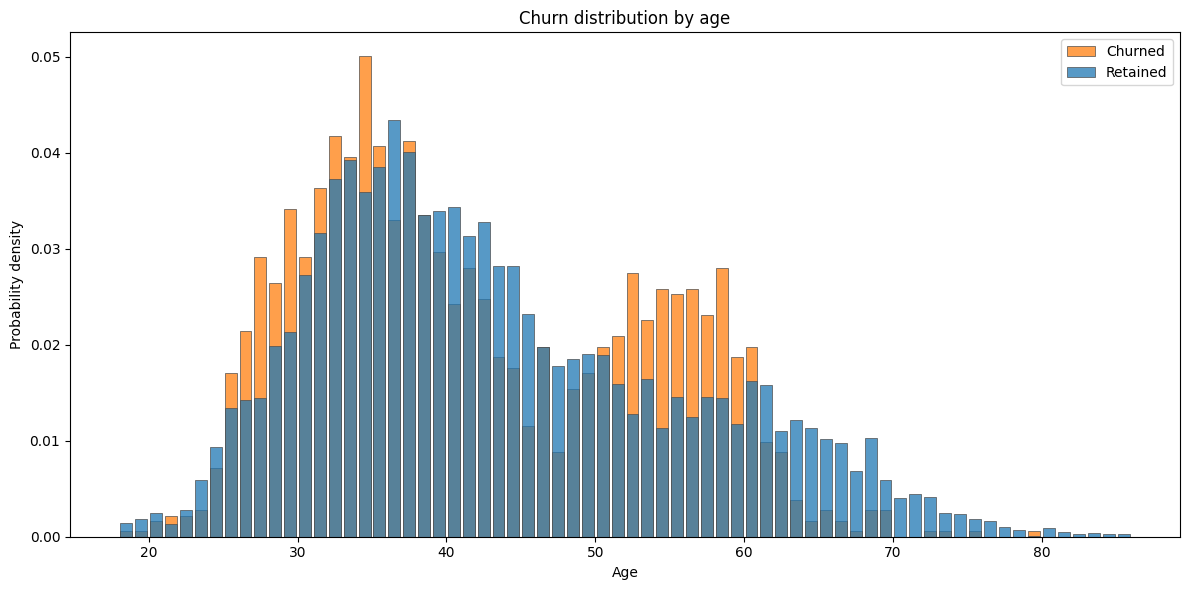

In [167]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart - 1 bar = 1 year
sns.histplot(
    df_bank,
    x='age', 
    hue='churn',
    edgecolor='.3',
    linewidth=.5,
    binwidth=1,
    stat='density',
    common_norm=False,
    shrink=.8,
    alpha=.75
)
plt.legend(
    title='', 
    labels=[
        f"{'Churned' if group == True else 'Retained'}" 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by age')
plt.ylabel('Probability density')
plt.xlabel('Age')
plt.tight_layout()
plt.show()


<div style="border:solid gray 1px; padding: 20px">

**Conclusion**
1. More male customers are under **50**, while older than 50 more customers are female

2. Men may be more likely to churn

3. Potential churn-prone age segments:

   - **26 - 30** years
   - **32, 33, 35** years
   - **52 - 61** years


### Analysis of equity scores

Let's visualize how churn probability changes depending on equity score.


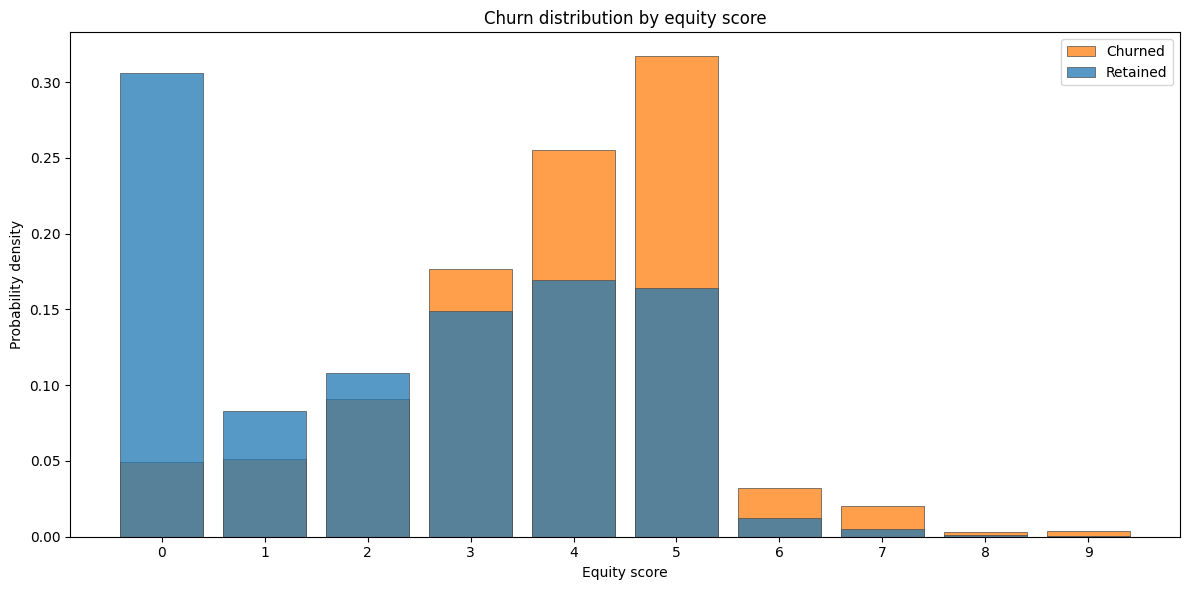

In [168]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x='equity', 
    hue='churn',
    edgecolor='.3',
    linewidth=.5,
    stat='density',
    discrete=True,
    common_norm=False,
    shrink=.8,
    alpha=.75
)
plt.legend(
    title='', 
    labels=[
        f"{'Churned' if group == True else 'Retained'}" 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by equity score')
plt.ylabel('Probability density')
plt.xlabel('Equity score')
plt.xticks(df_bank['equity'].unique())
plt.tight_layout()
plt.show()


<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**

1. Most customers have **0** or **5** equity score

2. A potential churn-prone segment: equity score **4**


### Account balance analysis
Let's visualize the distribution of customer account balances.


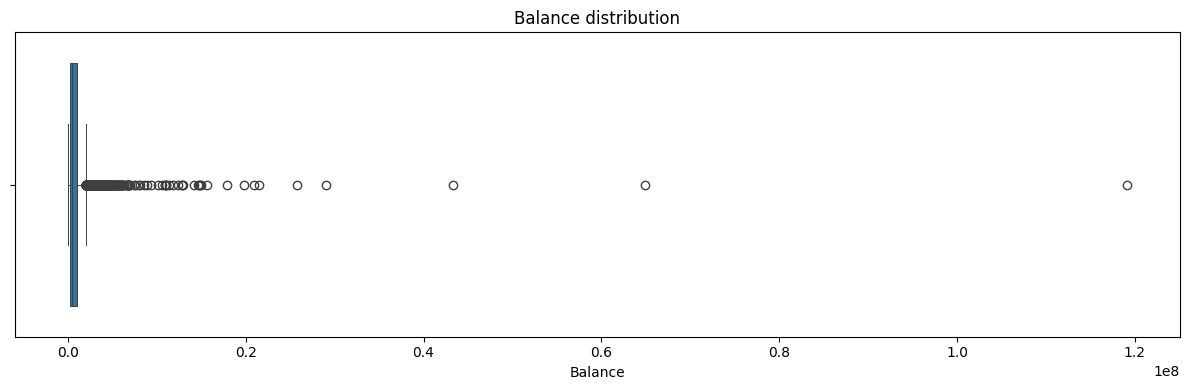

In [169]:
# plot balance distribution
plt.figure(figsize=(12, 4))
sns.boxplot(
    data=df_bank,
    x='balance',
    linewidth=.7
)
plt.title('Balance distribution')
plt.ylabel('')
plt.xlabel('Balance')
plt.tight_layout()
plt.show()


Let's visualize how churn probability changes depending on account balance. To get a clearer picture, exclude outliers from the plot.


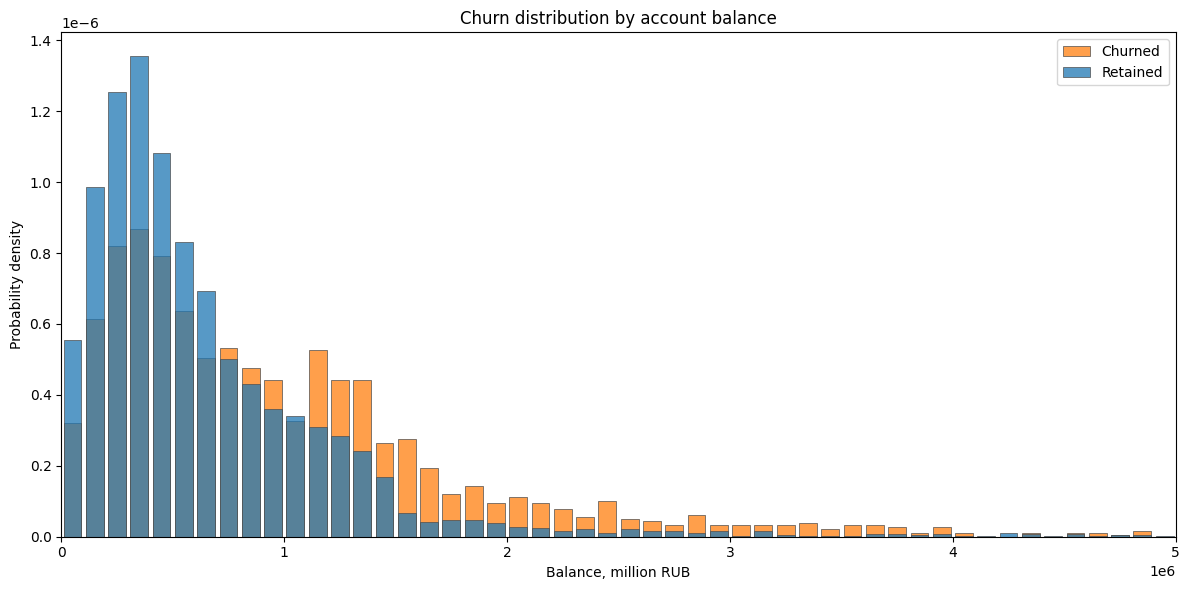

In [170]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x='balance', 
    hue='churn',
    edgecolor='.3',
    linewidth=.5,
    binwidth=100000,
    stat='density',
    common_norm=False,
    shrink=.8,
    alpha=.75
)
plt.legend(
    title='', 
    loc='upper right',
    labels=[
        f"{'Churned' if group == True else 'Retained'}" 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by account balance')
plt.ylabel('Probability density')
plt.xlabel('Balance, million RUB')
plt.xlim(0,5000000)
plt.tight_layout()
plt.show()


<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**

1. Up to **50** years old there are more male customers, while over 50 there are more female customers

2. Men may be more likely to churn

3. Potential age segments likely to churn:

   - **26 - 30** years
   - **32, 33, 35** years
   - **52 - 61** years

### Credit card ownership analysis

Visualize churn probability by credit card ownership.

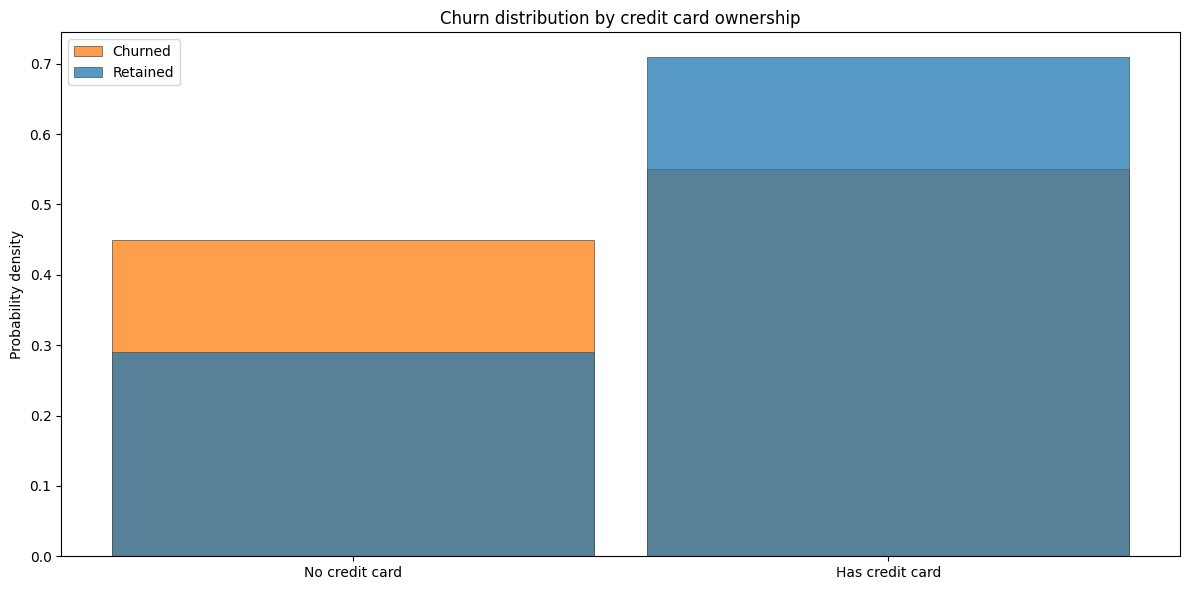

In [171]:
# set figure size 
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x='credit_card', 
    hue='churn',
    edgecolor=".3",
    linewidth=.5,
    discrete=True,
    stat='density',
    common_norm=False,
    shrink=.9,
    alpha=.75
)
plt.legend(
    title='', 
    loc='upper left',
    labels=[
        f'{"Churned" if group == True else "Retained"}' 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by credit card ownership')
plt.ylabel('Probability density')
plt.xlabel('')
plt.xticks(ticks=[0, 1], labels=['No credit card', 'Has credit card'])
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusion:**

1. More customers have a credit card

2. Potential churn-prone segment: **without a credit card**

### Customer activity analysis

Visualize churn probability by customer activity.

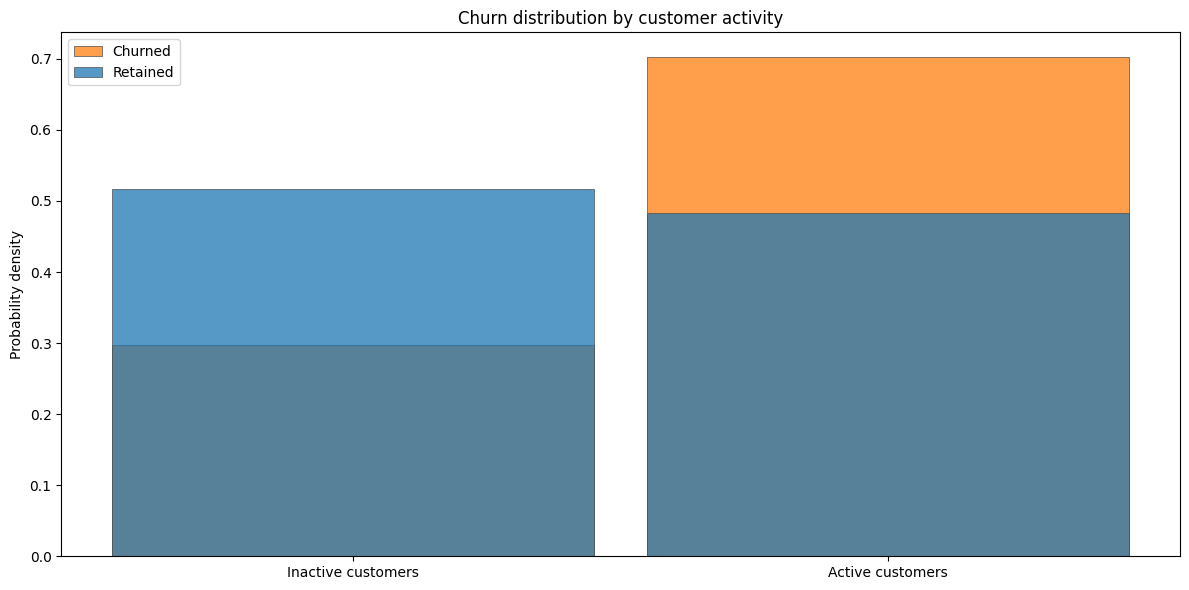

In [172]:
# set figure size 
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x='last_activity', 
    hue="churn",
    edgecolor=".3",
    linewidth=.5,
    discrete=True,
    stat='density',
    common_norm=False,
    shrink=.9,
    alpha=.75
)
plt.legend(
    title='', 
    loc='upper left',
    labels=[
        f'{"Churned" if group == True else "Retained"}' 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by customer activity')
plt.ylabel('Probability density')
plt.xlabel('')
plt.xticks(ticks=[0, 1], labels=['Inactive customers', 'Active customers'])
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**

1. More active customers

2. Potential churn-prone segment: **active customers**

### Estimated income analysis

Visualize estimated customer income distribution.

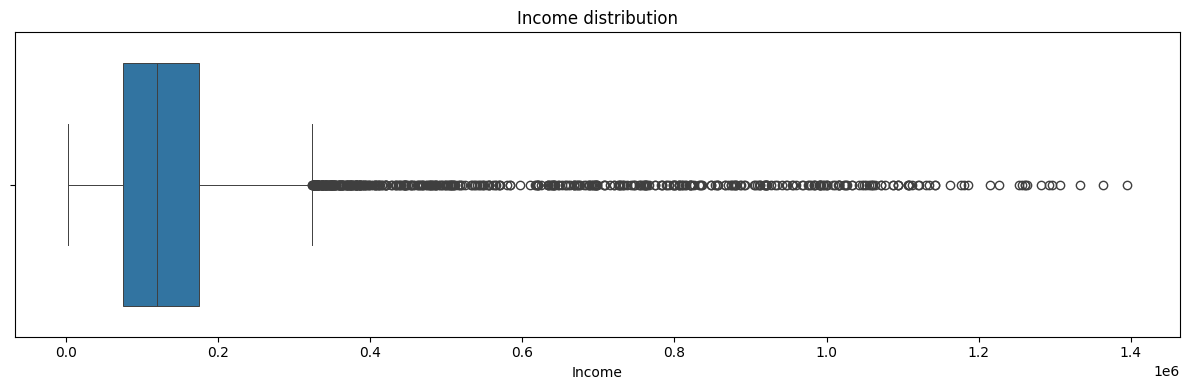

In [173]:
# plot average check distribution
plt.figure(figsize=(12, 4))
sns.boxplot(
data=df_bank,
x='est_salary',
linewidth=.7
)
plt.title('Income distribution')
plt.ylabel('')
plt.xlabel('Income')
plt.tight_layout()
plt.show()

Visualize churn probability by estimated income. Exclude plot outliers for clearer analysis.

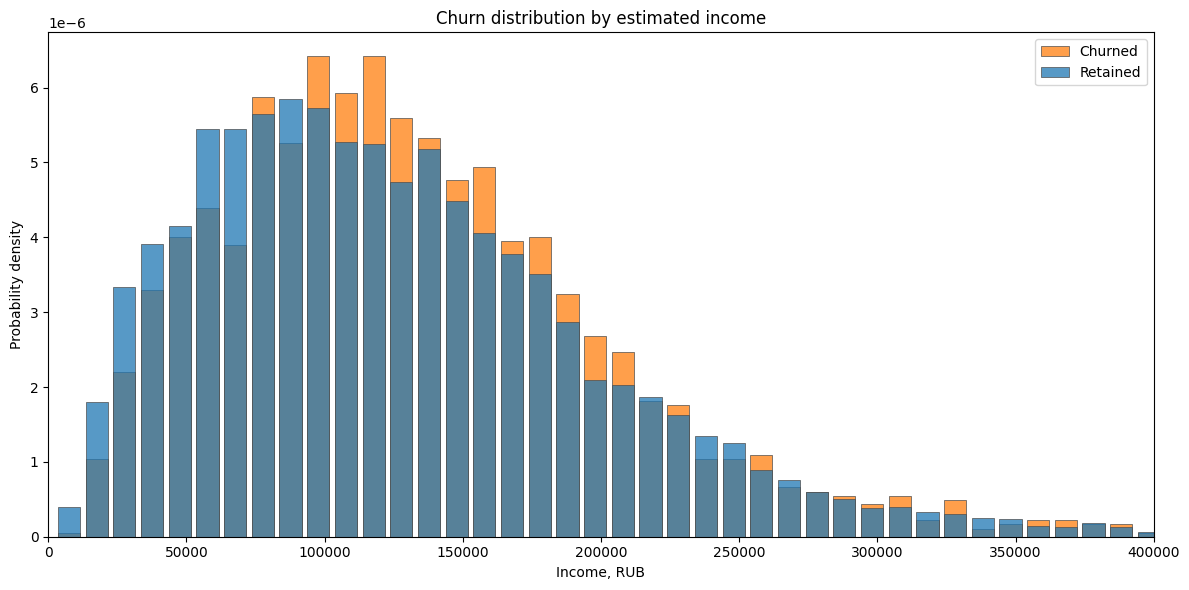

In [174]:
# set figure size 
plt.figure(figsize=(12, 6))

# plot chart
sns.histplot(
    df_bank,
    x="est_salary", 
    hue="churn",
    edgecolor=".3",
    linewidth=.5,
    binwidth=10000,
    stat='density',
    common_norm=False,
    shrink=.8,
    alpha=.75
)
plt.legend(
    title='', 
    loc='upper right',
    labels=[
        f'{"Churned" if group == True else "Retained"}' 
        for group in df_bank['churn'].unique()
    ]
)
plt.title('Churn distribution by estimated income')
plt.ylabel('Probability density')
plt.xlabel('Income, RUB')
plt.xlim(0,400000)
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusions:**

1. Most customers have an estimated income of **100** thousand RUB.
   
2. Potential churn-prone segment: income from **100** to **210** thousand RUB.

### Correlation matrix of customer features

Evaluate relationships using the `phi_k` correlation coefficient, adapted for categorical, ordinal, and interval variables. Display feature correlations on a heatmap.

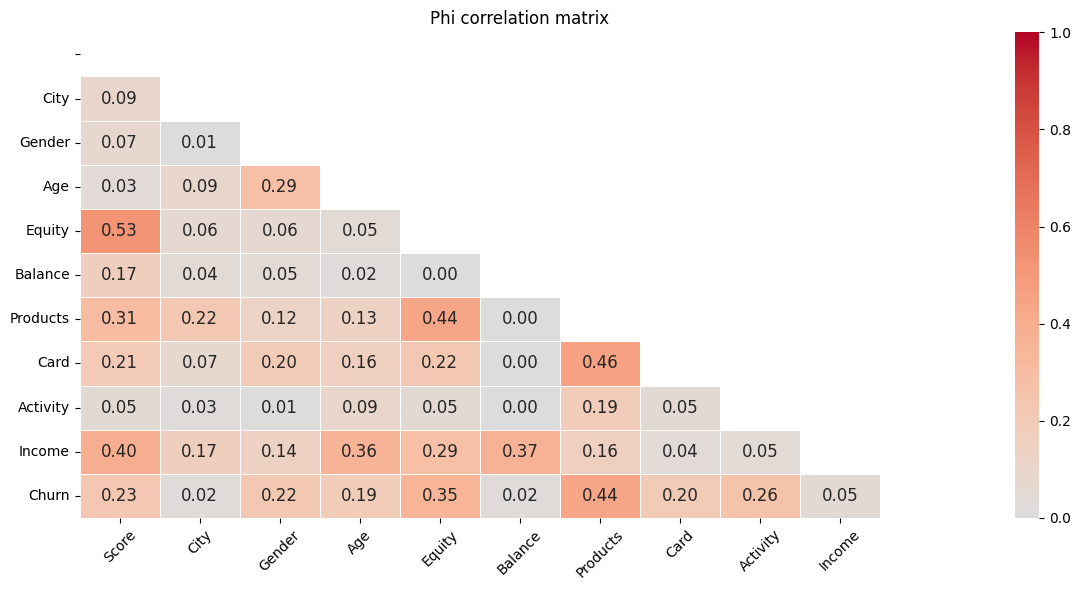

In [175]:
# prepare dataframe
df_phik = df_bank.drop(columns=['userid'])

# specify interval variables
interval_cols = ['score', 'age', 'balance', 'est_salary']

# construct correlation matrix
phik_corr = df_phik.phik_matrix(interval_cols=interval_cols)

# set figure size 
plt.figure(figsize=(12, 6))

# hide upper triangle
mask = np.triu(np.ones_like(phik_corr, dtype=bool))

# plot chart
ax = sns.heatmap(
    data=phik_corr,
    vmax=1,
    annot=True,
    mask=mask,
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    fmt=".2f",
    annot_kws={'size':12},
    xticklabels=[
        'Score', 
        'City', 
        'Gender', 
        'Age', 
        'Equity', 
        'Balance', 
        'Products', 
        'Card', 
        'Activity', 
        'Income'],
    yticklabels=[
        '', 
        'City', 
        'Gender', 
        'Age', 
        'Equity', 
        'Balance', 
        'Products', 
        'Card', 
        'Activity', 
        'Income',
        'Churn'],
)
plt.title('Phi correlation matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border:solid gray 1px; padding: 20px">

**Conclusions on moderate positive feature correlations:**

1. Customer churn is related to the number of bank products used and equity ownership
   
2. Credit score is related to equity ownership and estimated income

3. Number of products used is related to equity ownership and credit card ownership

4. Balance is related to customer income, which is related to age

<a id="analyze_segment"></a>
## High churn segment analysis

Criterion: at least 500 customers and churn share of 30% or higher.

Create a function to calculate high-churn segments.

In [176]:
# create a segment calculation function
def segment_churn(unique_values, interval_value):
    results = []
    
    # iterate over features
    for feature1 in unique_values.keys():
        for feature2 in unique_values.keys():
            if feature1 != feature2:
                
                if feature1 in interval_value:
                    query_feature1 = (
                        f"({unique_values[feature1][0]} <= {feature1} "
                        f"<= {unique_values[feature1][1]})"
                    )
                else:
                    query_feature1 = f"({feature1} == {repr(unique_values[feature1])})"
                
                if feature2 in interval_value:
                    query_feature2 = (
                        f"({unique_values[feature2][0]} <= {feature2} "
                        f"<= {unique_values[feature2][1]})"
                    )
                else:
                    query_feature2 = f"({feature2} == {repr(unique_values[feature2])})"
                
                query_string = f"{query_feature1} & {query_feature2}" 
                query_string = query_string.replace("age1", "age").replace("age2", "age")
                
                filtered_df = df_bank.query(query_string)
                total_clients = len(filtered_df)
                churn_clients = filtered_df['churn'].sum()
                churn_rate = filtered_df['churn'].mean() if total_clients > 0 else None
                
                results.append({
                    'feature1': f"{feature1} {unique_values[feature1]}",
                    'feature2': f"{feature2} {unique_values[feature2]}",
                    'total_clients': total_clients,
                    'churn_clients': churn_clients,
                    'churn_rate': churn_rate
                })
    
    # build segments dataframe
    results_df = pd.DataFrame(results)
    results_df = \
    (
        results_df
        .drop_duplicates(subset=['total_clients', 'churn_rate'])
        .query('(500 <= total_clients) & (churn_rate >= 0.3)')
        .sort_values(by='churn_rate', ascending=False)
    )
    results_df['churn_rate'] = round(results_df['churn_rate'], 2)
    pd.set_option('display.max_colwidth', 30)
    
    # display top 10 churn share segments
    message = (
        f"\n\n**Top 10 segments by churn share**"
    )
    if flag_md == 1:
        display(Markdown(message))
    else:
        print(message.replace("*", ""))
    display(results_df.head(10))

Create a dictionary of churn-prone feature intervals identified during exploratory analysis and build a churn segment table sorted by descending churned customer count.

In [177]:
# create a dictionary of high-churn feature intervals
unique_values = {
    'score': (830, 900),
    'products': (3,5),
    'age1': (26, 35),
    'age2': (52, 61),
    'equity': (4, 9),
    'balance': (1200000, 4000000),
    'est_salary': (100000, 210000),
    'credit_card': False,
    'last_activity': True,
    'gender': "М"    
}
interval_value = ['score', 'products', 'age', 'age', 'equity', 'balance', 'est_salary']

# construct high-churn segments
segment_churn(unique_values, interval_value)



**Top 10 segments by churn share**

,feature1,feature2,total_clients,churn_clients,churn_rate
52,"balance (1200000, 4000000)",last_activity True,642,367,0.57
53,"balance (1200000, 4000000)",gender М,657,350,0.53
17,"products (3, 5)",gender М,752,376,0.50
51,"balance (1200000, 4000000)",credit_card False,627,303,0.48
50,"balance (1200000, 4000000)","est_salary (100000, 210000)",674,323,0.48
16,"products (3, 5)",last_activity True,824,391,0.47
14,"products (3, 5)","est_salary (100000, 210000)",659,304,0.46
12,"products (3, 5)","equity (4, 9)",953,426,0.45
40,"equity (4, 9)","balance (1200000, 4000000)",945,416,0.44
0,"score (830, 900)","products (3, 5)",629,267,0.42


<div style="border:solid gray 1px; padding: 20px">

**Key insight:**

Customers with high credit scores, 3 or more products, active accounts, no credit card, and high balance / income were the most churn-prone segments.

Next, we will verify whether balance and salary differences are statistically significant between churned and retained customers.

</div>

<a id="hypothesis"></a>
## Hypothesis testing

### Hypothesis about income differences between churned and retained customers

Let's formulate hypotheses:

**H0** - null hypothesis:
- there is no difference in income between churned and retained customers

**H1** - alternative two-sided hypothesis
- there is a difference in income between churned and retained customers

Because income contains outliers, we will test the hypothesis using the two-sided Mann-Whitney U test for independent samples. If the probability of incorrectly rejecting the null hypothesis `p-value` is less than the significance level `alpha = 5%`, we reject the null hypothesis in favor of the alternative.

Let's visualize the distribution of average customer income, for example by equity score.


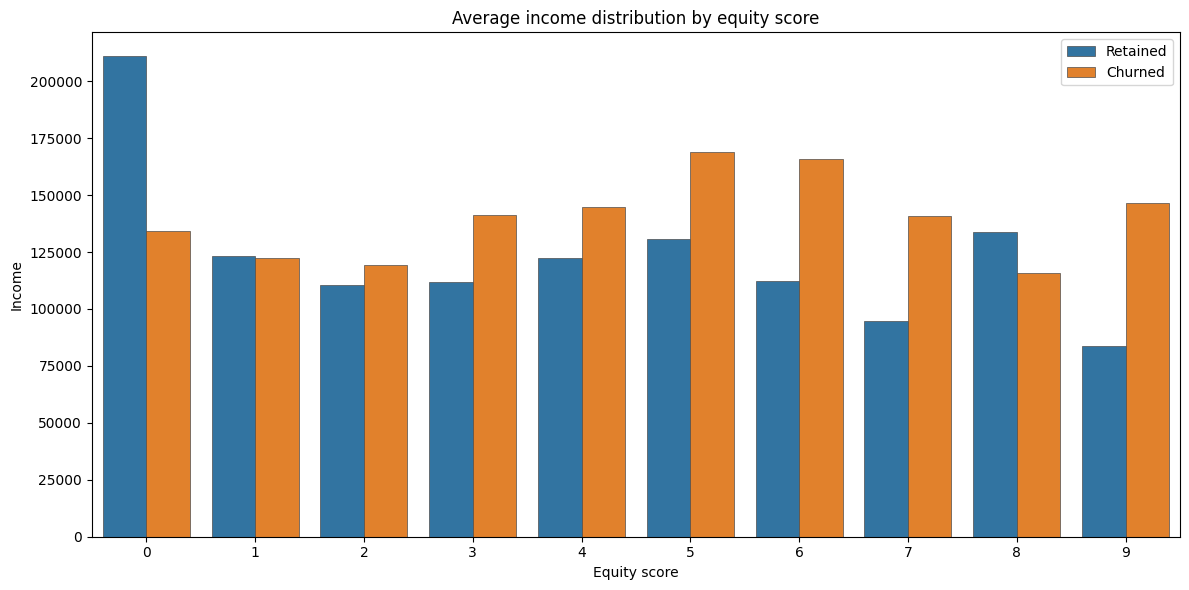

In [178]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart
sns.barplot(
    data=df_bank,
    x='equity',
    y='est_salary',
    edgecolor='.3',
    linewidth=.5,
    hue='churn',
    errorbar=None
)
plt.legend(
    title='', 
    loc='upper right',
    labels=[
        f"{'Churned' if group == True else 'Retained'}" 
        for group in sorted(df_bank['churn'].unique())
    ]
)
plt.title('Average income distribution by equity score')
plt.ylabel('Income')
plt.xlabel('Equity score')
plt.tight_layout()
plt.show()


Visual inspection suggests average incomes differ between churned and retained customers. Let's test statistical significance.


In [179]:
# churned customers dataframe
df_true = df_bank.query('churn == True')

# retained customers dataframe
df_false = df_bank.query('churn == False')

# set significance level
alpha = 0.05

# perform Mann-Whitney U test with two-sided alternative
p_value = st.mannwhitneyu(
    df_true['est_salary'],
    df_false['est_salary'],
    alternative='two-sided'
)[1]

# evaluate hypothesis
if p_value < alpha:
    message = (
        f'p_value=**{p_value:.2e}** < {alpha:.2%}'
        f' Reject the null hypothesis: '         f'there are statistically significant differences in income between churned and retained customers.'
    )
else:
    message = (
        f'p_value=**{p_value:.2%}** >= {alpha:.2%}'
        f' Failed to reject the null hypothesis: '         f'there is no statistically significant difference in income between churned and retained customers.'
    )

if flag_md == 1:
    display(Markdown(message))
else:
    print(message.replace('*', ''))


p_value=**2.44e-04** < 5.00% Reject the null hypothesis: there are statistically significant differences in income between churned and retained customers.

<div style="border:solid gray 1px; padding: 20px">

**Conclusion:**

1. Differences in income between churned and retained customers are statistically significant


### Hypothesis about different ages for churned and retained customers

Let's formulate hypotheses:

**H0** - null hypothesis:
- there is no difference in age between churned and retained customers

**H1** - alternative two-sided hypothesis
- there is a difference in age between churned and retained customers

Because age distribution is close to normal and there are no outliers, we will test the hypothesis using Student's t-test for independent samples. If the probability of incorrectly rejecting the null hypothesis `p-value` is less than the significance level `alpha = 5%`, we reject the null hypothesis in favor of the alternative.

Let's visualize the distribution of average customer age, for example by equity score.


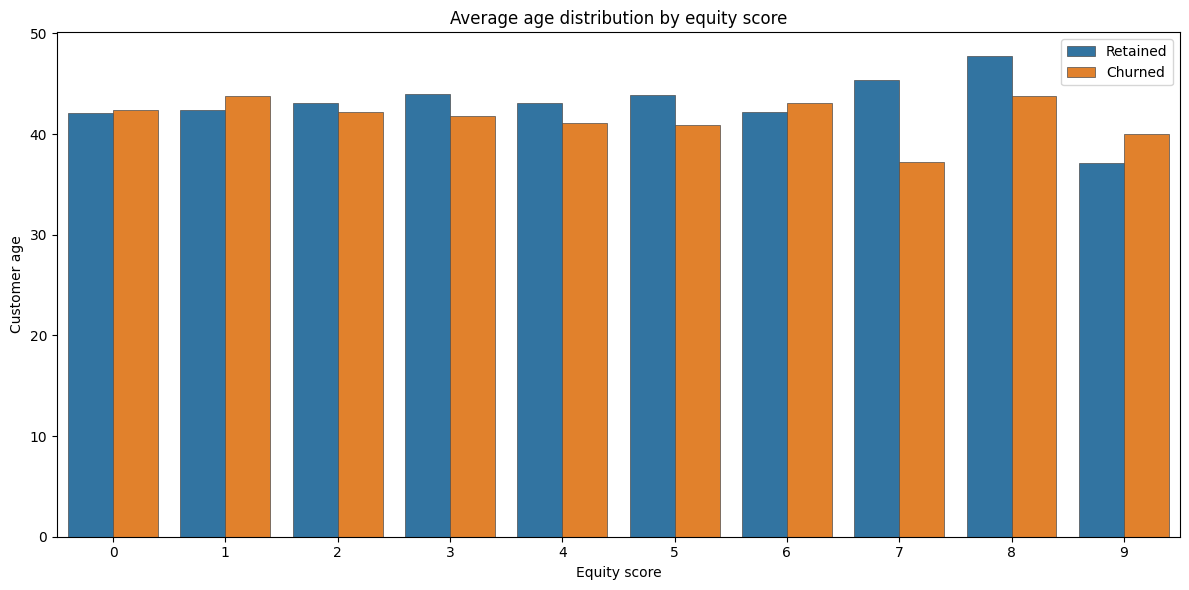

In [180]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart
sns.barplot(
    data=df_bank,
    x='equity',
    y='age',
    edgecolor='.3',
    linewidth=.5,
    hue='churn',
    errorbar=None
)
plt.legend(
    title='', 
    loc='upper right',
    labels=[
        f"{'Churned' if group == True else 'Retained'}" 
        for group in sorted(df_bank['churn'].unique())
    ]
)
plt.title('Average age distribution by equity score')
plt.ylabel('Customer age')
plt.xlabel('Equity score')
plt.tight_layout()
plt.show()


Visual inspection suggests average age differs between churned and retained customers. Let's test statistical significance.


In [181]:
# churned customers dataframe
df_true = df_bank.query('churn == True').dropna(subset=['age'])

# retained customers dataframe
df_false = df_bank.query('churn == False').dropna(subset=['age'])

# set significance level
alpha = 0.05

# perform t-test with two-sided alternative
p_value = st.ttest_ind(
    df_true['age'],
    df_false['age'],
    alternative='two-sided'
)[1]

# evaluate hypothesis
if p_value < alpha:
    message = (
        f'p_value=**{p_value:.2e}** < {alpha:.2%}'
        f' Reject the null hypothesis: '         f'there are statistically significant differences in age between churned and retained customers.'
    )
else:
    message = (
        f'p_value=**{p_value:.2%}** >= {alpha:.2%}'
        f' Failed to reject the null hypothesis: '         f'there is no statistically significant difference in age between churned and retained customers.'
    )

if flag_md == 1:
    display(Markdown(message))
else:
    print(message.replace('*', ''))


p_value=**6.50e-07** < 5.00% Reject the null hypothesis: there are statistically significant differences in age between churned and retained customers.

<div style="border:solid gray 1px; padding: 20px">

**Conclusion:**

1. Differences in age between churned and retained customers are statistically significant


### Hypothesis about the effect of customer activity on churn probability

Let's formulate hypotheses:

**H0** - null hypothesis:
- there is no difference in churn share between active and inactive customers

**H1** - alternative two-sided hypothesis
- there is a difference in churn share between active and inactive customers

We will test the hypothesis using a Z-test for proportions. If the probability of incorrectly rejecting the null hypothesis `p-value` is less than the significance level `alpha = 5%`, we reject the null hypothesis in favor of the alternative.

Let's visualize churn shares, for example by city.


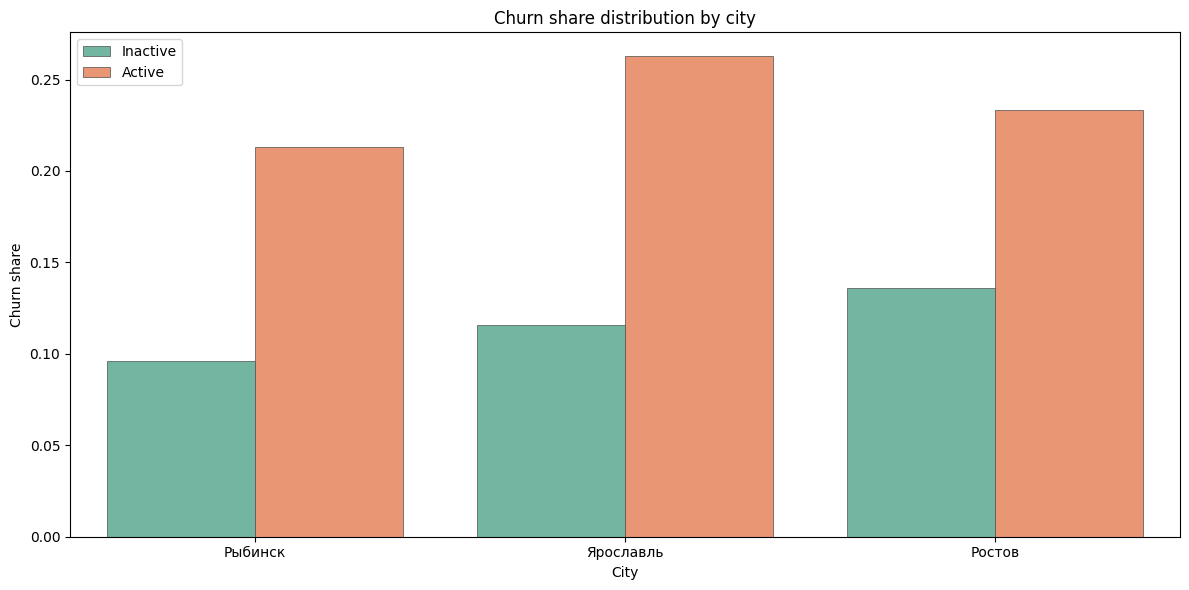

In [182]:
# set figure size
plt.figure(figsize=(12, 6))

# plot chart
palette = sns.color_palette('Set2', n_colors=2)
sns.barplot(
    data=df_bank,
    x='city',
    y='churn',
    edgecolor='.3',
    linewidth=.5,
    hue='last_activity',
    palette=palette,
    errorbar=None
)
plt.legend(
    title='', 
    loc='upper left',
    labels=[
        f"{'Active' if group == True else 'Inactive'}" 
        for group in sorted(df_bank['churn'].unique())
    ]
)
plt.title('Churn share distribution by city')
plt.ylabel('Churn share')
plt.xlabel('City')
plt.tight_layout()
plt.show()


Visual inspection suggests churn shares differ between active and inactive customers. Let's test statistical significance.


In [183]:
# count active customers
trials1 = df_bank.query('last_activity == True')['userid'].count()

# count churned active customers
successes1 = df_bank.query('churn == True & last_activity == True')['userid'].count()

# count inactive customers
trials2 = df_bank.query('last_activity == False')['userid'].count()

# count churned inactive customers
successes2 = df_bank.query('churn == True & last_activity == False')['userid'].count()

# churn share among active customers
p1 = successes1/trials1

# churn share among inactive customers
p2 = successes2/trials2

# calculate p-value
p_value = proportions_ztest([successes1,successes2],[trials1,trials2])[1]

# display churn share information
message = (
    f'In the active customer group, churn share: **{p1:.2%}**'
    f'In the inactive customer group, churn share: **{p2:.2%}**'
)

# evaluate hypothesis
message1 = (
    f'p_value=**{p_value:.2e}** < {alpha:.2%}'
    f' Reject the null hypothesis: there is a statistically significant difference between the shares.'
) if p_value < alpha else (
    f'p_value=**{p_value:.2%}** >= {alpha:.2%}'
    f'Failed to reject the null hypothesis: '
    f'there is no statistically significant basis to consider the shares different')

# display using Markdown if available
if flag_md == 1:
    display(Markdown(message))
    display(Markdown(message1))
else:
    print(message.replace('*', ''))
    print(message1.replace('*', ''))


In the active customer group, churn share: **24.41%**In the inactive customer group, churn share: **11.37%**

p_value=**6.67e-64** < 5.00% Reject the null hypothesis: there is a statistically significant difference between the shares.

<div style="border:solid gray 1px; padding: 20px">

**Conclusion:**

1. Customer activity has a statistically significant effect on churn probability


<a id="research_results"></a>
## Research results

The findings can help Metanprom bank management reduce customer churn.

[Presentation of the research results](https://disk.yandex.ru/i/4N8lRLVmxNufjw)

1. On average, **18%** of bank customers are likely to churn

2. Profile of a typical churn-prone customer:

   - Equity score of **4** or higher
   - Actively uses bank services
   - More likely male than female
   - High credit score from **830**
   - Does not have a credit card
   - Income from **100** to **200**k RUB

4. Top 3 high-churn segments:

   - Active customers with equity score of **4** or higher
   - Men with equity score of **4** or higher
   - Active customers with credit score from **830**

6. Additional potential churn-prone segments:

   - used **3** or more bank products
   - ages: **26 - 35** years and **52 - 61** years
   - account balance from **1.2** to **4** million RUB

8. There is a moderate positive correlation between features:

   - churn is related to the number of bank products used and equity ownership
   - credit score is related to equity ownership and estimated income
   - number of products used is related to equity ownership and credit card ownership
   - balance level is related to income, which is related to age

7. Statistically significant differences were found:

   - in income between churned and retained customers
   - in age between churned and retained customers
   - in churn share between active and inactive customers

**Recommendations for customer retention:**

1. Collect customer feedback regularly to adapt offers and products
2. Offer special deposit rates, such as a higher rate for large deposits
3. Offer premium bank cards with bonus programs and cashback for purchases in selected categories
4. Develop special loan products for customers with high credit scores and no credit card
5. Provide quick access to bank specialists without visiting a branch
6. Create marketing campaigns targeted at their interests, for example in investments or lending


[Back to top](#intro)
